# Compare two different VAE structures

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
import torch
from pathlib import Path

In [2]:
class VAE_ori(nn.Module):
    def __init__(self, n_target, latent_dim):
        # Call parent model constructor and store hidden state variables.
        super().__init__()
        self.latent_dim = latent_dim
        self.n_target = n_target
        self.T = 50
        self.channels = 32

        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=self.n_target, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.Conv1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.Conv1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
        )

        self.mean_map = nn.Linear(self.channels * self.T, self.latent_dim)

        self.std_map = nn.Linear(self.channels * self.T, self.latent_dim)

        self.fc_decoder = nn.Sequential(
            nn.Linear(self.latent_dim, self.channels * self.T),
            nn.LeakyReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.n_target, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU()
        )

    def sample(self, mean, log_var):
        """Sample a given N(0,1) normal distribution given a mean and log of variance."""

        # First compute the variance from the log variance.
        var = torch.exp(0.5 * log_var)

        # Compute a scaled distribution
        eps = torch.randn_like(var)

        # Add the vectors
        z = mean + var * eps

        return z

    def forward(self, X):
        """Forward propogate through the model, return both the reconstruction and sampled mean and standard deviation
        for the system.
        """
        pre_code = self.encoder(X)
        B, C, L = pre_code.shape
        flattened = pre_code.view(B, C * L)

        mu = self.mean_map(flattened)
        log_var = self.std_map(flattened)

        code = self.sample(mu, log_var)

        # Pass through FC layers before decoding
        post_code = self.fc_decoder(code)

        X_hat = self.decoder(post_code.view(B, C, L))

        return X_hat, code, mu, log_var

In [3]:
class VAE_dl(nn.Module): # double linear layer variational autoencoder

    def __init__(self, n_target, latent_dim):
        # Call parent model constructor and store hidden state variables.
        super().__init__()
        self.latent_dim = latent_dim
        self.n_target = n_target
        self.T = 50
        self.channels = 32

        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=self.n_target, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.Conv1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
            nn.Conv1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(),
        )

        self.mean_map = nn.Sequential(
            nn.Linear(self.channels * self.T, 64),
            nn.LeakyReLU(),
            nn.Linear(64, self.latent_dim)
        )

        self.std_map = nn.Sequential(
            nn.Linear(self.channels * self.T, 64),
            nn.LeakyReLU(),
            nn.Linear(64, self.latent_dim)
        )

        self.fc_decoder = nn.Sequential(
            nn.Linear(self.latent_dim, 64),
            nn.LeakyReLU(),
            nn.Linear(64, self.channels * self.T),
            nn.LeakyReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.channels, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU(),
            nn.ConvTranspose1d(in_channels=self.channels, out_channels=self.n_target, kernel_size=3, stride=1,
                               padding=1),
            nn.LeakyReLU()
        )

    def sample(self, mean, log_var):
        """Sample a given N(0,1) normal distribution given a mean and log of variance."""

        # First compute the variance from the log variance.
        var = torch.exp(0.5 * log_var)

        # Compute a scaled distribution
        eps = torch.randn_like(var)

        # Add the vectors
        z = mean + var * eps

        return z

    def forward(self, X):
        """Forward propogate through the model, return both the reconstruction and sampled mean and standard deviation
        for the system.
        """
        pre_code = self.encoder(X)
        B, C, L = pre_code.shape
        flattened = pre_code.view(B, C * L)

        mu = self.mean_map(flattened)
        log_var = self.std_map(flattened)

        code = self.sample(mu, log_var)

        # Pass through FC layers before decoding
        post_code = self.fc_decoder(code)

        X_hat = self.decoder(post_code.view(B, C, L))

        return X_hat, code, mu, log_var

In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

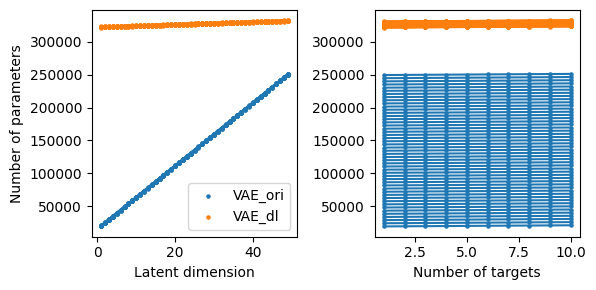

In [7]:
colors = ["tab:blue","tab:orange"]
fig,axes=plt.subplots(1,2,figsize=(6,3))
ax1,ax2=axes
NT = np.arange(1,11,1)
E = np.arange(1,50,1)
p_vae_ori = np.zeros((len(NT),len(E)))
p_vae_dl = np.zeros((len(NT),len(E)))
for i,n_target in enumerate(NT):
    for j,n_embedding in enumerate(E):
        model = VAE_ori(n_target=n_target, latent_dim=n_embedding)
        p_vae_ori[i,j] = count_parameters(model)
        model = VAE_dl(n_target=n_target, latent_dim=n_embedding)
        p_vae_dl[i,j] = count_parameters(model)
for i, n_target in enumerate(NT):
    ax1.plot(E,p_vae_ori[i,:],ls='-',color=colors[0])
    ax1.scatter(E,p_vae_ori[i,:],color=colors[0],s=5,label="VAE_ori" if n_target==1 else "")
    ax1.plot(E,p_vae_dl[i,:],ls='-',color=colors[1])
    ax1.scatter(E,p_vae_dl[i,:],color=colors[1],s=5,label="VAE_dl" if n_target==1 else "")
for j, n_embedding in enumerate(E):
    ax2.plot(NT,p_vae_ori[:,j],ls='-',color=colors[0])
    ax2.scatter(NT,p_vae_ori[:,j],color=colors[0],s=5,label="VAE_ori" if n_embedding==1 else "")
    ax2.plot(NT,p_vae_dl[:,j],ls='-',color=colors[1])
    ax2.scatter(NT,p_vae_dl[:,j],color=colors[1],s=5,label="VAE_dl" if n_embedding==1 else "")
ax1.set_xlabel("Latent dimension")
ax2.set_xlabel("Number of targets")
ax1.set_ylabel("Number of parameters")
ax1.legend()
fig.tight_layout()

In [8]:
from scipy.optimize import curve_fit

def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y

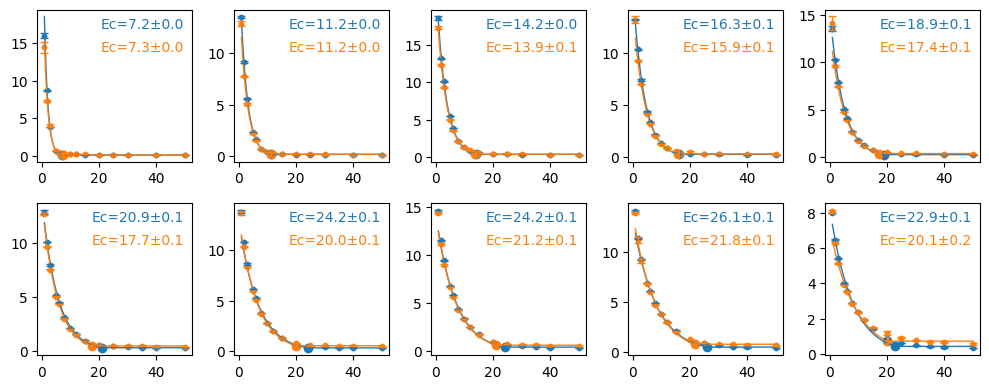

In [11]:
colors = ["tab:blue","tab:orange"]
NT=np.arange(1,11,1)
n_ori=100
n_trial = 5
glv_type="b"
sim_type="random"
model_index=3
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    data1=np.loadtxt(f"../../simulations/VAE_gLV_simulation/saved_data/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data2=np.loadtxt(f"./saved_data/VAE_dl/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    for i,data in enumerate([data1, data2]):
        N_EBD=data[0,:]
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        ax.scatter(N_EBD,mean_FUV,s=10,c=colors[i],label=["gLV","VAE-dl"][i])
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',c=colors[i],elinewidth=1,capsize=3,zorder=10)
        
        popt, pcov = curve_fit(y_exp, N_EBD, mean_FUV, sigma=se_FUV, absolute_sigma=True, 
                            p0=(10+n_target, 0.5, 0.2))
        Ec = popt[0]
        param_errors = np.sqrt(np.diag(pcov))# estimate the standard errors of the fitted parameters
        Ec_se = param_errors[0]
        Ec_data[1,i]=Ec
        Ec_data[2,i]=Ec_se
        y_Ec = y_exp(np.array([Ec]),*popt)
        ax.scatter(Ec,y_Ec,c=colors[i])
        ax.errorbar(Ec,y_Ec,xerr=Ec_se,fmt='none',c=colors[i],elinewidth=1,capsize=3,zorder=10)
        xx=np.linspace(1,50,1000)
        yy=y_exp(xx,*popt)
        ax.plot(xx,yy,linewidth=1)
        ax.text(x=0.95,y=0.95-0.15*i,s="Ec=%1.1f±%1.1f"%(Ec,Ec_se),c=colors[i],
            ha="right",va="top",transform=ax.transAxes)
    #ax.set_yscale("log")
    #ax.set_ylim([0.01,10])
    if i==5:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
fig.tight_layout()

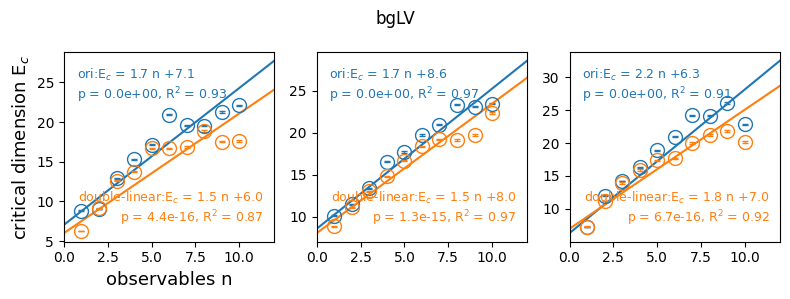

In [26]:
from scipy.optimize import curve_fit
from scipy.stats import t

# Linear model
def linear_model(x, a, b):
    return a * x + b

glv_type="b"
sim_type="random"
fig,axes = plt.subplots(1,3,figsize=(8,3))
axes=axes.flat
for i,model_index in enumerate([1,2,3]):
    ax=axes[i]
    data1 = np.loadtxt(f"../../simulations/VAE_gLV_simulation/saved_data/{glv_type}gLV/Ec_{glv_type}gLV_model{model_index}_{sim_type}.txt")
    data2 = np.loadtxt(f"./saved_data/VAE_dl/{glv_type}gLV/Ec_{glv_type}gLV_model{model_index}_{sim_type}.txt")
    for i,data in enumerate([data1, data2]):
        # Extract x, y, and CI bounds
        N_TG = data[0,:]
        Ec = data[1,:]
        Ec_se = data[2,:]
        ax.errorbar(N_TG,Ec,Ec_se,marker="o",c=colors[i],mfc="None",capsize=2,lw=0,markersize=10,
                        elinewidth=1)
        
        # Weighted fit using standard errors
        popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
        slope, intercept = popt
        slope_se, intercept_se = np.sqrt(np.diag(pcov))
    
        # Compute t-statistic and p-value
        dof = len(N_TG) - 2
        t_stat = slope / slope_se
        p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))

        # residuals and total sums of squares
        y_pred = linear_model(N_TG, slope, intercept)
        SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
        SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)
        
        R2 = 1 - SS_res / SS_tot
        
        # Generate fit line and CI band
        x_fit = np.linspace(0, 12, 100)
        y_fit = linear_model(x_fit, slope, intercept)

        ax.plot(x_fit,y_fit,c=colors[i],ls='-')
        ax.set_xlim([0, 12])

        # Format regression equation
        txt = (f"E$_c$ = {slope:.1f} n {intercept:+.1f}\n"
        f"p = {p_value:.1e}, R$^2$ = {R2:.2f}")
        if i==0:
            ax.text(x=0.06, y=0.75 - 0.2*i, c = colors[i], s="ori:"+txt, transform=ax.transAxes, fontsize=9)
        else:
            ax.text(x=0.95, y=0.1, c = colors[i], s="double-linear:"+txt, transform=ax.transAxes, ha="right", fontsize=9)
ax=axes[0]
ax.set_xlabel("observables n", fontsize=13)
ax.set_ylabel("critical dimension E$_c$", fontsize=13)
fig.suptitle(f"{glv_type}gLV")
fig.tight_layout()